In [90]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict


In [91]:
load_dotenv()


True

In [92]:
class ParallelWorkflow(TypedDict):
    text_input: str
    uppercase: str
    lowercase: str
    reversed_text: str
    word_count: int
    final_output: str 
    

In [93]:
def UpperCaseValue(state:ParallelWorkflow):
    text=state['text_input']
    return {'uppercase': text.upper()} # Changed to uppercase



In [94]:
def LowerCaseValue(state:ParallelWorkflow):
    text=state['text_input']
    return {'lowercase': text.lower()} # Changed to lowercase
    

In [95]:
def ReverseString(state:ParallelWorkflow):
    text=state['text_input']
    return {'reversed_text': text[::-1]} # Changed to reversed_text

In [96]:

def WordCount(state:ParallelWorkflow):
    text=state['text_input']
    return {'word_count': len(text.split())}


In [97]:
def Combine(state:ParallelWorkflow):
    return {
        "final_output": f"""
Uppercase: {state['uppercase']}
Lowercase: {state['lowercase']}
Word Count: {state['word_count']}
Reversed: {state['reversed_text']}
"""
    } # Removed Combine:{state['Combine']} as it does not exist in the state


In [98]:

graph=StateGraph(ParallelWorkflow)

graph.add_node('UpperCase',UpperCaseValue)
graph.add_node('LowerCase',LowerCaseValue)
graph.add_node('Reverse',ReverseString)
graph.add_node('WordCount',WordCount)
graph.add_node('Combine',Combine)

In [99]:
graph.add_edge(START,'UpperCase')
graph.add_edge(START,'LowerCase')
graph.add_edge(START,'WordCount')
graph.add_edge(START,'Reverse')

graph.add_edge('UpperCase','Combine')
graph.add_edge('LowerCase','Combine')
graph.add_edge('WordCount','Combine')
graph.add_edge('Reverse','Combine')

graph.add_edge('Combine',END)

In [100]:
workflow=graph.compile()

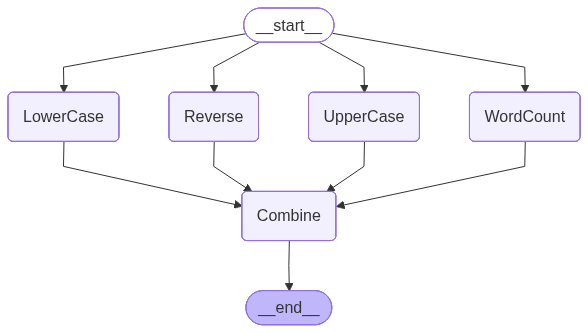

In [101]:
workflow

In [104]:
result = workflow.invoke({
    "text_input": "Hello Mudassar Hussain"
})

print(result["final_output"])


Uppercase: HELLO MUDASSAR HUSSAIN
Lowercase: hello mudassar hussain
Word Count: 3
Reversed: niassuH rassaduM olleH

